# 17.3 Spatio-Temporal Poisson Kriging with PyGStat


**Dataset:** North-Atlantic-seaboard US county lung/bronchus cancer (LBC) mortality panel (`data/lbc_atlantic.csv`, 666 counties × 1998–2012) + polygons (`data/COUNTY_ATLANTIC.shp`) + population (`data/lbc_rate.csv`)
**Target:** Age-adjusted LBC mortality rate (per 100,000)
**Library:** `pygstat.STPoisson_kriging` — space-time Poisson kriging with a metric ST covariance (Goovaerts, 2006; Pebesma, 2012)


***
## Table of Contents

1. [Overview](#1-overview)
2. [Theory - Why Poisson Kriging](#2-theory--why-poisson-kriging)
3. [Theory - Ordinary Kriging with a Poisson Reliability Term](#3-theory--ordinary-kriging-with-a-poisson-reliability-term)
4. [Theory - Space-Time Covariance](#4-theory--space-time-covariance)
5. [Theory - Spatio-Temporal Poisson Kriging](#5-theory--spatio-temporal-poisson-kriging)
6. [Python Setup](#6-python-setup)
7. [Load the Atlantic LBC Panel](#7-load-the-atlantic-lbc-panel)
8. [Exploratory Maps](#8-exploratory-maps)
9. [Train / Test Split](#9-train--test-split)
10. [Empirical Semivariogram and Space-Time Model Fit](#10-empirical-semivariogram-and-space-time-model-fit)
11. [Fit Spatio-Temporal Poisson Kriging](#11-fit-spatio-temporal-poisson-kriging)
12. [Validation on Held-Out Counties](#12-validation-on-held-out-counties)
13. [Leave-One-Out Sanity Check](#13-leave-one-out-sanity-check)
14. [Forecast Beyond the Observed Range](#14-forecast-beyond-the-observed-range)
15. [Error-Handling Checks](#15-error-handling-checks)
16. [CPU vs GPU Poisson Kriging Timing](#16-cpu-vs-gpu-poisson-kriging-timing)
17. [Summary and Conclusions](#17-summary-and-conclusions)
18. [Resources](#18-resources)


***
## 1. Overview

**Spatio-temporal Poisson kriging** extends Goovaerts' Poisson kriging from a single map of areal rates to a *panel*: the same counties observed every year. Each observation is an area-year $(v_i, t_i)$ with a rate $z(v_i,t_i)$ and a population $n(v_i)$. The estimator is still a Best Linear Unbiased Estimator of the latent risk $R$, but the covariance now depends on **both** a spatial lag and a temporal lag, and the Poisson reliability term still down-weights small-population counties.

`pygstat.STPoissonKriging` combines the population-reliability diagonal of `PoissonKriging` with the space-time covariance engine of `pygstat.krige_st` (a Python port of gstat's `krigeST`). This notebook tests it on lung/bronchus cancer mortality along the North Atlantic seaboard, 1998–2012, then times the k-NN batched solve on the **national** LBC panel.

| Step | What we do |
|---|---|
| Data | 666 counties × 15 years of LBC rates; one population figure per county |
| Split | Hold out 60 counties entirely (~9%); train on the remaining 606 |
| Variogram | Empirical space-time semivariogram; fit a **metric** ST model |
| ST Poisson kriging | Fit `STPoissonKriging`; predict with a local neighbourhood |
| Validation | Predict every held-out county-year vs a naive-mean baseline |
| Forecast | Predict 2013 (one year past the observed window) |
| CPU / GPU | Time `STPoissonKriging.predict` on national LBC + `US_COUNTY.shp` |


***
## 2. Theory - Why Poisson Kriging

Each county's mortality rate is computed from a count over a population at risk,

$$
z(\mathbf u_i) = B\,\frac{d(\mathbf u_i)}{n(\mathbf u_i)}, \qquad
d(\mathbf u_i)\sim\mathrm{Poisson}\!\big(n(\mathbf u_i)\,R(\mathbf u_i)\big),
$$

where $d$ is the observed count, $n$ the population at risk, $R$ the underlying (latent) risk, and $B$ a rate base (e.g. $100{,}000$). Because a Poisson count has $\mathrm{Var}(d)=\mathbb E[d]$, the rate itself is heteroscedastic:

$$
\mathrm{Var}\big(z(\mathbf u_i)\big) \;\approx\; B\,\frac{m^\ast}{n(\mathbf u_i)},
\qquad
m^\ast=\frac{\sum_i d(\mathbf u_i)}{\sum_i n(\mathbf u_i)}
      =\frac{\sum_i n(\mathbf u_i)\,z(\mathbf u_i)/B}{\sum_i n(\mathbf u_i)}.
$$

A county with a small population has a far noisier rate than one with a large population, even if their *true* underlying risk is identical. Kriging the raw rate ignores this and lets small, noisy counties distort the map. **Poisson kriging** (Goovaerts, 2006) corrects for this by folding $\mathrm{Var}(z(\mathbf u_i))$ into the kriging system itself, as a population-dependent term on the diagonal.


***
## 3. Theory - Ordinary Kriging with a Poisson Reliability Term

The risk estimator is linear, $\hat R(\mathbf u_0,t_0)=\sum_i\lambda_i\,z(\mathbf u_i,t_i)$, with the usual unbiasedness constraint $\sum_i\lambda_i=1$. The weights solve

$$
\sum_{j=1}^{N}\lambda_j\Big[C\big((\mathbf u_i,t_i)-(\mathbf u_j,t_j)\big)
     +\delta_{ij}\,B\,\frac{m^\ast}{n(\mathbf u_i)}\Big] + \mu
     = C\big((\mathbf u_i,t_i)-(\mathbf u_0,t_0)\big), \quad i=1,\dots,N,
$$

or, in matrix form with Lagrange multiplier $\mu$,

$$
\begin{bmatrix} \mathbf V + B\,\mathrm{diag}\!\left(\dfrac{m^\ast}{n_i}\right) & \mathbf 1 \\[4pt]
                 \mathbf 1^\top & 0 \end{bmatrix}
\begin{bmatrix} \boldsymbol\lambda \\ \mu \end{bmatrix}
=
\begin{bmatrix} \mathbf v_0 \\ 1 \end{bmatrix},
$$

with prediction $\hat R=\boldsymbol\lambda^\top\mathbf z$ and kriging variance $\sigma^2 = C(0) - \boldsymbol\lambda^\top\mathbf v_0 - \mu$. This is exactly `pygstat.poisson_kriging.PoissonKriging`, restricted to areas observed once (no time dimension).


***
## 4. Theory - Space-Time Covariance

An area-year panel (the same 666 counties, each observed every year from 1998–2012) needs $C$ as a function of *both* a spatial lag $h_s=\lVert\mathbf u_i-\mathbf u_j\rVert$ and a temporal lag $h_t=|t_i-t_j|$. This notebook uses the **metric** space-time model (Pebesma, 2012), the simplest choice when there is no strong prior for separate spatial/temporal structure: space and time are folded into one joint (anisotropic) distance

$$
h_{st} = \sqrt{h_s^2 + (a\,h_t)^2},
$$

where $a$ (`stAni`, units of space per unit time, e.g. meters/year) makes space and time commensurable, and a single ordinary variogram/covariance model $C(h_{st})$ is fit to it. `pygstat.st_variogram_models` also implements `separable`, `productSum`, and `sumMetric` space-time models for cases with distinct spatial/temporal structure.

The empirical semivariogram is the Matheron estimator, binned jointly by spatial and temporal lag:

$$
\hat\gamma(h_s,h_t) = \frac{1}{2\,|N(h_s,h_t)|}
   \sum_{(i,a),(j,b)\,\in\,N(h_s,h_t)}
   \big(z(\mathbf u_i,t_a)-z(\mathbf u_j,t_b)\big)^2,
$$

where $N(h_s,h_t)$ collects area-year pairs whose spatial distance falls in the $h_s$ bin and whose time difference equals $h_t$.


***
## 5. Theory - Spatio-Temporal Poisson Kriging

`STPoissonKriging` combines Sections 3 and 4: the kriging system of Section 3, but with $C$ the fitted space-time covariance of Section 4 (via `pygstat.krige_st.cov_fn_st`), evaluated on a local neighbourhood of the `number_of_neighbors` nearest area-years in a scaled $(x, y, a\cdot t)$ space. It reduces to `PoissonKriging` when every area has one time stamp, and to plain space-time ordinary kriging when every population is equal.


***
## 6. Python Setup

### 6.1 CPU and GPU

`STPoissonKriging.predict` solves a local space-time Poisson-kriging system at every
prediction point. Every point has the same neighbor count $k$, so pygstat stacks the
systems into one `(n_{\mathrm{pred}}, k+1, k+1)` batched `xp.linalg.solve` — NumPy on
CPU, CuPy on GPU. Pass `use_gpu='auto'|True|False` to the constructor.

| Argument / method | What it controls |
|-------------------|------------------|
| `use_gpu` | Batched k-NN ST Poisson-kriging solve (NumPy or CuPy). |
| `predict` | k-NN stacked solve; GPU when `use_gpu` is true. |
| `predict_id` | Leave-one-out of a single area-year; stays on **CPU**. |

`use_gpu` is:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` and stores the result in
`USE_GPU`. The Atlantic maps in §7–15 use `use_gpu='auto'`. **§16** times CPU vs GPU
on the **national LBC panel** (`LBC_1998_2012_USA.csv` joined to `US_COUNTY.shp`).

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pygstat
from pygstat import STPoissonKriging, empirical_st_variogram, fit_metric_st_variogram
from pygstat.st_variogram_models import vgm, vgm_st, variogram_line
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

print("pygstat version:", pygstat.__version__)

# ── ST Poisson k-NN batched solve: CPU / GPU dispatch (CuPy) ───────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU (CuPy)      : {name}")
    except Exception:
        print("GPU (CuPy)      : available")
    print("Backend         : GPU (CuPy) — STPoissonKriging k-NN batched solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")

# --- running test log, rendered as a styled summary table at the end ---
RESULTS = []
def record(test, status, details=""):
    RESULTS.append({"Test": test, "Status": status, "Details": details})
    print(f"[{status}] {test} -- {details}")


pygstat version: 0.1.0
CuPy            : 14.2.0
GPU (CuPy)      : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — STPoissonKriging k-NN batched solve on GPU
use_gpu         : True


***
## 7. Load the Atlantic LBC Panel

* `data/lbc_atlantic.csv` — wide panel, one row per county (`FIPS`), one column per year 1998–2012, age-adjusted lung/bronchus cancer mortality rate per 100,000.
* `data/COUNTY_ATLANTIC.shp` (+ `.dbf`/`.shx`/`.prj`) — the 666 county polygons, with `FIPS` and projected centroid attributes `x`, `y` (Albers Equal Area, meters).
* `data/lbc_rate.csv` — supplies each county's **population** (`pop`), which `COUNTY_ATLANTIC.shp` does not carry.

**Population caveat.** `lbc_rate.csv` gives one population figure per county (its approximate population over the study period), not a year-by-year series. True Poisson kriging needs population *at the time of each count*; lacking that, population is treated as constant across 1998–2012 for every county — a limitation of the available data, not of the method.


In [2]:
atlantic = pd.read_csv("../data/lbc_atlantic.csv")
year_cols = [c for c in atlantic.columns if c != "FIPS"]
ok = (atlantic.shape[0] == 666) and (not atlantic.isna().any().any())
record("Load lbc_atlantic.csv (wide rate panel)", "PASS" if ok else "FAIL",
       f"shape={atlantic.shape}, years={year_cols[0]}-{year_cols[-1]}")
atlantic.head()

[PASS] Load lbc_atlantic.csv (wide rate panel) -- shape=(666, 16), years=1998-2012


,FIPS,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012
0,13111,73.093158,73.340521,74.998020,74.670522,74.792901,74.630005,73.067522,73.197047,72.328557,69.507780,69.635923,68.906045,68.280212,68.506526,69.105148
1,42115,61.739041,62.442799,62.570395,62.075383,62.222949,60.757341,58.974677,58.865642,58.402923,57.813455,57.975761,54.991348,54.868356,55.036873,54.039593
2,42075,62.616826,63.269599,63.503806,62.786999,62.229980,63.073503,61.781815,61.573635,60.254389,58.860604,59.363198,58.047576,58.057350,58.075406,56.655123
3,51683,75.722528,73.114699,74.560122,70.685068,68.871166,66.457912,62.219449,60.894387,58.516792,57.475568,55.636156,52.695484,50.575438,48.580099,47.475127
4,36057,61.922597,62.743832,62.516029,63.280348,62.323007,62.009105,60.043889,59.994602,59.748146,58.062513,56.766709,55.660304,54.818243,54.210314,54.119502


In [3]:
counties = gpd.read_file("../data/COUNTY_ATLANTIC.shp")
counties["FIPS"] = counties["FIPS"].astype(int)
ok = (len(counties) == 666) and (set(counties["FIPS"]) == set(atlantic["FIPS"]))
record("Load COUNTY_ATLANTIC.shp county polygons", "PASS" if ok else "FAIL",
       f"{len(counties)} polygons, FIPS match={set(counties['FIPS'])==set(atlantic['FIPS'])}")
counties[["FIPS", "x", "y", "STATE", "COUNTY"]].head()

[PASS] Load COUNTY_ATLANTIC.shp county polygons -- 666 polygons, FIPS match=True


,FIPS,x,y,STATE,COUNTY
0,13111,1056523.936,1376613.190,Georgia,Fannin County
1,42115,1653442.064,2267301.476,Pennsylvania,Susquehanna County
2,42075,1633708.275,2096683.059,Pennsylvania,Lebanon County
3,51683,1584048.852,1901443.401,Virginia,Manassas city
4,36057,1735811.102,2409536.493,New York,Montgomery County


In [4]:
rate_meta = pd.read_csv("../data/lbc_rate.csv")
counties_pop = counties.merge(rate_meta[["FIPS", "pop"]], on="FIPS", how="left")
ok = counties_pop["pop"].notna().all() and (counties_pop["pop"] > 0).all()
record("Merge per-county population from lbc_rate.csv", "PASS" if ok else "FAIL",
       f"pop range=({counties_pop['pop'].min():.0f}, {counties_pop['pop'].max():.0f})")

[PASS] Merge per-county population from lbc_rate.csv -- pop range=(3075, 2153528)


In [5]:
long = atlantic.melt(id_vars="FIPS", value_vars=year_cols, var_name="year", value_name="rate")
long["year"] = long["year"].astype(int)
long = long.merge(counties_pop[["FIPS", "x", "y", "pop"]], on="FIPS", how="left")
long = long.sort_values(["FIPS", "year"]).reset_index(drop=True)
ok = (long.shape[0] == 666 * 15) and (not long.isna().any().any())
record("Build long area-year panel", "PASS" if ok else "FAIL", f"shape={long.shape}")
long.head()

[PASS] Build long area-year panel -- shape=(9990, 6)


,FIPS,year,rate,x,y,pop
0,10001,1998,77.531300,1737530.538,1972072.594,272234.0
1,10001,1999,79.687342,1737530.538,1972072.594,272234.0
2,10001,2000,77.296116,1737530.538,1972072.594,272234.0
3,10001,2001,79.104085,1737530.538,1972072.594,272234.0
4,10001,2002,77.125457,1737530.538,1972072.594,272234.0


***
## 8. Exploratory Maps


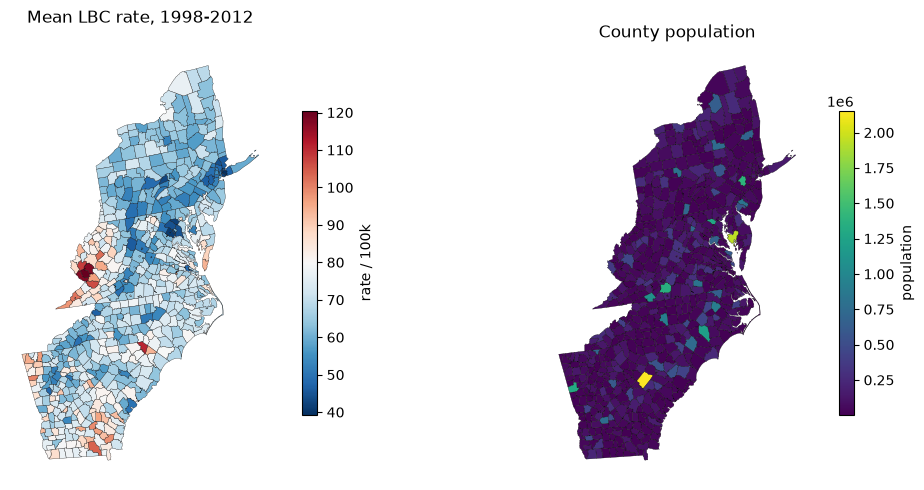

In [6]:
mean_rate = long.groupby("FIPS")["rate"].mean().rename("mean_rate")
map_df = counties_pop.merge(mean_rate, on="FIPS")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
map_df.plot("mean_rate", cmap="RdBu_r", legend=True, ax=ax[0], edgecolor="k", linewidth=0.2,
            legend_kwds={"label": "rate / 100k", "shrink": .7})
ax[0].set_title("Mean LBC rate, 1998-2012")
map_df.plot("pop", cmap="viridis", legend=True, ax=ax[1], edgecolor="k", linewidth=0.2,
            legend_kwds={"label": "population", "shrink": .7})
ax[1].set_title("County population")
for a in ax:
    a.set_axis_off()
plt.tight_layout()
plt.show()

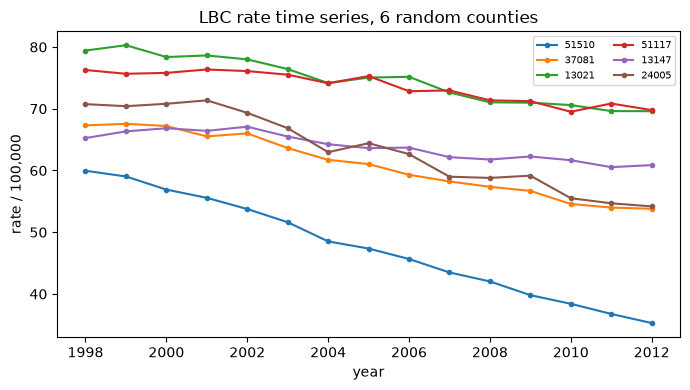

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sample_fips = long["FIPS"].drop_duplicates().sample(6, random_state=0)
for fips in sample_fips:
    sub = long[long["FIPS"] == fips].sort_values("year")
    ax.plot(sub["year"], sub["rate"], marker="o", ms=3, label=str(fips))
ax.set_xlabel("year"); ax.set_ylabel("rate / 100,000")
ax.set_title("LBC rate time series, 6 random counties")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

***
## 9. Train / Test Split

To validate genuine spatial-temporal *extrapolation*, 60 counties (~9%) are held out **entirely** — none of their years are seen during training — and predicted purely from their space-time neighbours among the remaining 606 counties.


In [8]:
rng = np.random.default_rng(0)
fips_all = long["FIPS"].unique()
test_fips = rng.choice(fips_all, size=60, replace=False)
is_test = long["FIPS"].isin(test_fips)
train = long.loc[~is_test].reset_index(drop=True)
test = long.loc[is_test].reset_index(drop=True)
print(f"train: {train['FIPS'].nunique()} counties, {len(train)} rows")
print(f"test:  {test['FIPS'].nunique()} counties (held out), {len(test)} rows")

train: 606 counties, 9090 rows
test:  60 counties (held out), 900 rows


***
## 10. Empirical Semivariogram and Space-Time Model Fit

`empirical_st_variogram` needs a *complete* area × time matrix (every county observed every year); this holds for the training panel since whole counties — not scattered county-years — were held out.


In [9]:
train_wide = train.pivot(index="FIPS", columns="year", values="rate").sort_index()
train_coords = (train[["FIPS", "x", "y"]].drop_duplicates("FIPS").set_index("FIPS")
                 .loc[train_wide.index][["x", "y"]].to_numpy())
years = np.sort(train["year"].unique()).astype(float)

emp = empirical_st_variogram(train_coords, years, train_wide.to_numpy(), n_space_bins=12)
ok = (len(emp["dist"]) > 0) and np.all(np.isfinite(emp["gamma"])) and np.all(emp["gamma"] >= 0)
record("Empirical space-time variogram estimation", "PASS" if ok else "FAIL",
       f"{len(emp['dist'])} (space-bin, time-lag) cells from {emp['np'].sum():.0f} pairs")

[PASS] Empirical space-time variogram estimation -- 180 (space-bin, time-lag) cells from 34713630 pairs


In [10]:
fitted_model = fit_metric_st_variogram(emp)
joint = fitted_model["joint"]
nugget, sill, prange = joint[0]["psill"], joint[1]["psill"], joint[1]["range"]
st_ani = fitted_model["stAni"]
ok = (nugget >= 0) and (sill > 0) and (prange > 0) and (st_ani > 0) and np.isfinite(fitted_model["MSE"])
record("Fit 'metric' space-time variogram model", "PASS" if ok else "FAIL",
       f"nugget={nugget:.2f} sill={sill:.2f} range={prange:.0f}m stAni={st_ani:.0f}m/yr "
       f"MSE={fitted_model['MSE']:.3f}")

[PASS] Fit 'metric' space-time variogram model -- nugget=79.61 sill=124.60 range=575681m stAni=53938m/yr MSE=217.667


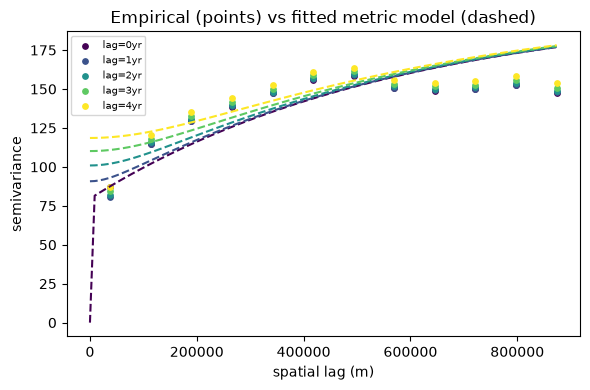

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
show_lags = sorted(set(emp["timelag"]))[:5]
colors = plt.cm.viridis(np.linspace(0, 1, len(show_lags)))
h = np.linspace(0, emp["dist"].max(), 100)
for lag, c in zip(show_lags, colors):
    m = emp["timelag"] == lag
    ax.scatter(emp["dist"][m], emp["gamma"][m], s=15, color=c, label=f"lag={lag:.0f}yr")
    hh = np.sqrt(h ** 2 + (st_ani * lag) ** 2)
    ax.plot(h, variogram_line(fitted_model["joint"], hh, covariance=False), "--", color=c)
ax.set_xlabel("spatial lag (m)"); ax.set_ylabel("semivariance")
ax.set_title("Empirical (points) vs fitted metric model (dashed)")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

***
## 11. Fit Spatio-Temporal Poisson Kriging


In [12]:
stpk = STPoissonKriging(fitted_model).fit(
    coords=train[["x", "y"]].to_numpy(),
    times=train["year"].to_numpy(float),
    values=train["rate"].to_numpy(),
    populations=train["pop"].to_numpy(),
    ids=train["FIPS"].to_numpy(),
)
ok = stpk.rate_base == 100000
record("Fit STPoissonKriging (auto-detected rate_base)", "PASS" if ok else "FAIL",
       f"rate_base={stpk.rate_base:.0f}")

[PASS] Fit STPoissonKriging (auto-detected rate_base) -- rate_base=100000


***
## 12. Validation on Held-Out Counties

Predict every county-year of the 60 held-out counties from their nearest space-time neighbours among the 606 training counties, and compare against a naive baseline (the overall training mean rate, i.e. no spatial or temporal information at all).


In [13]:
zhat, sig = stpk.predict(test[["x", "y"]].to_numpy(), test["year"].to_numpy(float),
                          number_of_neighbors=30)
test = test.assign(zhat=zhat, sig=sig)

resid = test["rate"] - test["zhat"]
rmse = float(np.sqrt(np.mean(resid ** 2)))
mae = float(np.mean(np.abs(resid)))
r2 = 1.0 - float(np.sum(resid ** 2)) / float(np.sum((test["rate"] - test["rate"].mean()) ** 2))
baseline_rmse = float(np.sqrt(np.mean((test["rate"] - train["rate"].mean()) ** 2)))

ok = rmse < baseline_rmse
record("Held-out county prediction accuracy (60 counties)", "PASS" if ok else "FAIL",
       f"RMSE={rmse:.2f} vs naive-mean RMSE={baseline_rmse:.2f}, R2={r2:.3f}, "
       f"mean kriging sd={test['sig'].mean():.2f}")

print(f"RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  naive-mean RMSE={baseline_rmse:.3f}")

[PASS] Held-out county prediction accuracy (60 counties) -- RMSE=8.55 vs naive-mean RMSE=13.46, R2=0.596, mean kriging sd=9.78
RMSE=8.553  MAE=6.849  R2=0.596  naive-mean RMSE=13.457


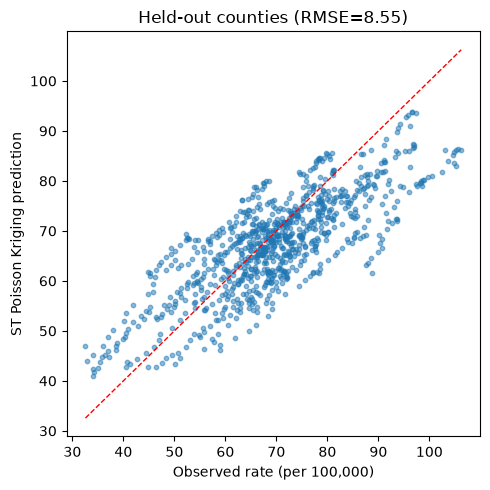

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(test["rate"], test["zhat"], s=10, alpha=0.5)
lims = [min(test["rate"].min(), test["zhat"].min()), max(test["rate"].max(), test["zhat"].max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Observed rate (per 100,000)")
ax.set_ylabel("ST Poisson Kriging prediction")
ax.set_title(f"Held-out counties (RMSE={rmse:.2f})")
plt.tight_layout()
plt.show()

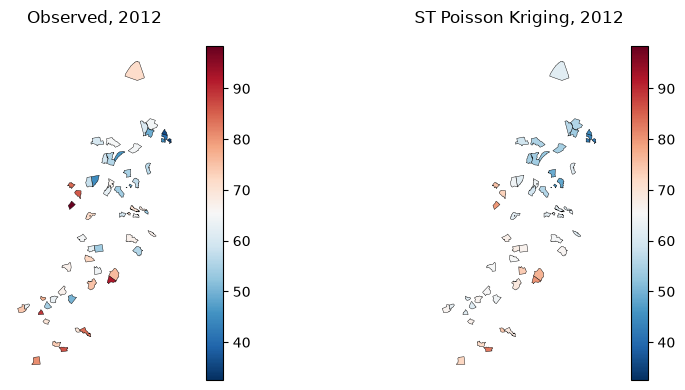

[PASS] Choropleth map: observed vs predicted (held-out, 2012) -- 60 counties mapped


In [15]:
snap = test[test["year"] == 2012].merge(counties[["FIPS", "geometry"]], on="FIPS")
snap = gpd.GeoDataFrame(snap, geometry="geometry", crs=counties.crs)
try:
    vmin, vmax = snap[["rate", "zhat"]].min().min(), snap[["rate", "zhat"]].max().max()
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    snap.plot("rate", ax=ax[0], legend=True, vmin=vmin, vmax=vmax, cmap="RdBu_r",
              edgecolor="k", linewidth=0.3)
    ax[0].set_title("Observed, 2012"); ax[0].set_axis_off()
    snap.plot("zhat", ax=ax[1], legend=True, vmin=vmin, vmax=vmax, cmap="RdBu_r",
              edgecolor="k", linewidth=0.3)
    ax[1].set_title("ST Poisson Kriging, 2012"); ax[1].set_axis_off()
    plt.tight_layout()
    plt.show()
    record("Choropleth map: observed vs predicted (held-out, 2012)", "PASS",
           f"{len(snap)} counties mapped")
except Exception as e:
    record("Choropleth map: observed vs predicted (held-out, 2012)", "BLOCKED", str(e))

***
## 13. Leave-One-Out Sanity Check

Ten random *training* area-years, each re-predicted with itself excluded from its own neighbour search — a basic sanity check that predictions track observed values without exactly reproducing them (they should be shrunk toward the local space-time mean, not copied).


In [16]:
sample = train.sample(10, random_state=0)
loo = pd.DataFrame([stpk.predict_id(row["FIPS"], row["year"], number_of_neighbors=30)
                     for _, row in sample.iterrows()])
loo["observed"] = sample["rate"].to_numpy()

ok = np.isfinite(loo["zhat"]).all() and (loo["sig"].fillna(0) >= 0).all()
record("Leave-one-out sanity check (10 training area-years)", "PASS" if ok else "FAIL",
       f"mean|zhat-observed|={np.mean(np.abs(loo['zhat']-loo['observed'])):.2f}")
loo[["id", "year", "observed", "zhat", "sig"]]

[PASS] Leave-one-out sanity check (10 training area-years) -- mean|zhat-observed|=5.84


,id,year,observed,zhat,sig
0,13033.0,2009.0,78.010072,73.443756,9.658588
1,36085.0,2008.0,53.816414,44.483592,9.652530
2,13023.0,2002.0,88.713051,74.796863,9.614405
3,37197.0,2011.0,67.353474,67.344757,9.788954
4,13181.0,2003.0,78.440312,72.865224,9.787427
5,13061.0,2007.0,65.153307,76.995327,9.795494
6,45089.0,2012.0,71.256596,68.008491,9.942256
7,37031.0,2011.0,69.517268,65.657153,10.160801
8,10005.0,2006.0,68.024194,70.850971,9.813167
9,13119.0,2009.0,71.449173,68.271225,9.682998


***
## 14. Forecast Beyond the Observed Range

Predicting a year past the observed 1998–2012 window is pure temporal extrapolation using the fitted space-time covariance — the space-time analogue of kriging a location past the edge of a spatial survey.


In [17]:
demo_fips = train["FIPS"].drop_duplicates().sample(3, random_state=0).to_numpy()
demo_coords = (train[["FIPS", "x", "y"]].drop_duplicates("FIPS").set_index("FIPS")
               .loc[demo_fips][["x", "y"]].to_numpy())
fzhat, fsig = stpk.predict(demo_coords, np.full(3, 2013.0), number_of_neighbors=30)

ok = np.all(np.isfinite(fzhat)) and np.all(fzhat > 0) and np.all(fzhat < 3 * long["rate"].max())
record("Forecast beyond observed range (2013)", "PASS" if ok else "FAIL",
       f"predictions={np.round(fzhat, 2).tolist()}")

for fips, zh, sg in zip(demo_fips, fzhat, fsig):
    last_obs = train.loc[train["FIPS"] == fips].sort_values("year").iloc[-1]["rate"]
    print(f"FIPS {fips}: 2012 observed={last_obs:.2f}  ->  2013 forecast={zh:.2f} +/- {sg:.2f}")

[PASS] Forecast beyond observed range (2013) -- predictions=[85.66, 63.84, 63.8]
FIPS 54043: 2012 observed=102.89  ->  2013 forecast=85.66 +/- 10.36
FIPS 13121: 2012 observed=46.79  ->  2013 forecast=63.84 +/- 10.26
FIPS 51570: 2012 observed=63.75  ->  2013 forecast=63.80 +/- 10.16


***
## 15. Error-Handling Checks

`STPoissonKriging` should fail loudly, not silently, on bad inputs.


In [18]:
try:
    stpk.predict_id(999999, 2000)
    record("Error handling: unknown (id, time) in predict_id", "FAIL", "no exception raised")
except ValueError as e:
    record("Error handling: unknown (id, time) in predict_id", "PASS", str(e))

[PASS] Error handling: unknown (id, time) in predict_id -- (id=999999, time=2000) not found in the fitted data


In [19]:
try:
    bad_pop = train["pop"].to_numpy().copy()
    bad_pop[0] = 0
    STPoissonKriging(fitted_model).fit(train[["x", "y"]].to_numpy(), train["year"].to_numpy(float),
                                        train["rate"].to_numpy(), bad_pop,
                                        ids=train["FIPS"].to_numpy())
    record("Error handling: non-positive population in fit()", "FAIL", "no exception raised")
except ValueError as e:
    record("Error handling: non-positive population in fit()", "PASS", str(e))

[PASS] Error handling: non-positive population in fit() -- populations must be strictly positive


In [20]:
try:
    stpk.predict(np.array([[0.0, 0.0]]), np.array([2005.0]), number_of_neighbors=1)
    record("Error handling: too few neighbors raises ValueError", "FAIL", "no exception raised")
except ValueError as e:
    record("Error handling: too few neighbors raises ValueError", "PASS", str(e))

[PASS] Error handling: too few neighbors raises ValueError -- Not enough space-time neighbors to build a kriging system (got 1); increase number_of_neighbors or check the data.


***
## 16. CPU vs GPU Poisson Kriging Timing

The 666-county Atlantic application is too small for a GPU comparison: host→device
copies dominate a stack of modest $(k+1)\times(k+1)$ systems. Here we time
**k-nearest-neighbor** space-time Poisson kriging (`STPoissonKriging.predict`) on
**CPU** (`use_gpu=False`) versus **GPU** (`use_gpu=True`) using the **national**
lung/bronchus cancer mortality panel.

Data:

1. Join `data/LBC_1998_2012_USA.csv` (3,107 counties × years 1998–2012) to
   `data/US_COUNTY.shp` on `FIPS`. Coordinates are NAD 1983 Albers metres (same CRS
   as the polygons).
2. The LBC CSV has no population column, and `US_COUNTY.shp` does not carry one
   either. County population is joined from `data/usa_diabetes_data.csv`
   (`POP_Total`) and treated as **constant across years** — the same proxy used
   for Atlantic `lbc_rate.pop`. `rate_base=100000`.
3. Hold a metric ST model fixed (Atlantic-scale exponential parameters). Fitting
   $\gamma$ is **not** in the times. Draw a separate prediction set in the county
   bounding box × 1998–2012.

The k-NN GPU work scales with **$n_{\mathrm{pred}}$** (one stacked solve of shape
`(n_pred, k+1, k+1)`). Training size is therefore held at all 46,605 county-years
and we vary $n_{\mathrm{pred}}$. Neighborhood size is $k=16$.

Each timing is the **median** of three `fit`+`predict` calls after a short GPU
warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel
here, the GPU column is skipped. `predict_id` (leave-one-out) is not timed: that
path is not a fixed-$k$ stack.


USA county LBC mortality (k-NN ST Poisson kriging)
  counties   : 3,107 joined on FIPS (LBC_1998_2012_USA.csv + US_COUNTY.shp + usa_diabetes POP_Total)
  area-years : 46,605  (3107 × 15 years)
  LBC rate   : [11.2, 223.6] per 100,000
  ST model   : metric Exp  nugget=79.61  sill=124.60  range=575681 m  stAni=53938 m/yr
  CRS        : NAD 1983 Albers (metres)

GPU usable : True
Repeats    : 3  (median wall time of fit+predict, k-NN)
n_train    : 46605  (USA LBC county-years)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random (x,y,t) in the US_COUNTY bbox × 1998–2012)
neighbors  : 16; rate_base=100000

dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
USA LBC    46605     500      21.2      17.9   1.19×   True
USA LBC    46605    1000      37.4      19.0   1.97×   True
USA LBC    46605    2000      63.3      23.9   2.65×   True
USA LBC    46605    4000     112.2      34.6   3.25×   True
USA LBC    46605    8000     223.8      57.2   3.91×   True



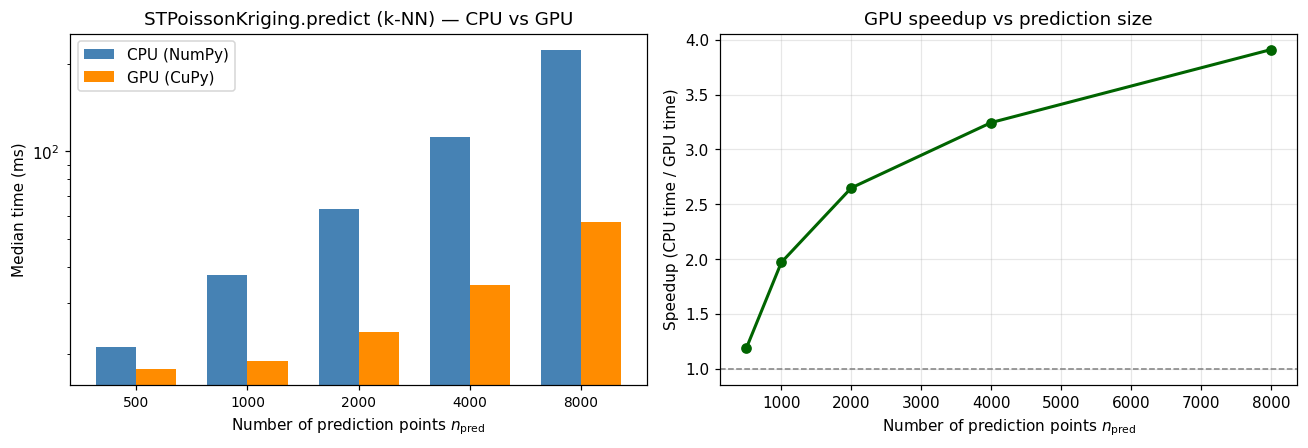

In [16]:
import time

N_REPEATS = 3
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
K = 16
RATE_BASE = 100000.0

df_lbc = pd.read_csv("../data/LBC_1998_2012_USA.csv")
gdf_cty = gpd.read_file("../data/US_COUNTY.shp")
df_pop = pd.read_csv("../data/usa_diabetes_data.csv")[["FIPS", "POP_Total"]]

df_lbc["FIPS"] = df_lbc["FIPS"].astype(int)
gdf_cty["FIPS"] = gdf_cty["FIPS"].astype(int)
df_pop["FIPS"] = df_pop["FIPS"].astype(int)

joined = gdf_cty.merge(df_lbc, on="FIPS", how="inner")
joined = joined.merge(df_pop, on="FIPS", how="inner")
joined = joined.dropna(subset=["LBC_MORTALITY_RATE", "POP_Total", "X", "Y", "Year"])
joined = joined[joined["POP_Total"] > 0].copy()

xy_train = joined[["X", "Y"]].to_numpy(dtype=float)
t_train = joined["Year"].to_numpy(dtype=float)
z_train = joined["LBC_MORTALITY_RATE"].to_numpy(dtype=float)
pop_train = joined["POP_Total"].to_numpy(dtype=float)
n_train = len(xy_train)
n_counties = joined["FIPS"].nunique()
n_years = joined["Year"].nunique()

xmin, ymin, xmax, ymax = gdf_cty.total_bounds
rng_sim = np.random.default_rng(42)
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))
t_pred_all = rng_sim.uniform(1998.0, 2012.0, size=N_PRED_MAX)

# Hold ST model fixed (Atlantic-scale metric params); fitting is not timed.
st_model = vgm_st(
    "metric",
    joint=vgm(psill=124.60, model="exponential", range_=575681.0, nugget=79.61),
    st_ani=53938.0,
)

print("USA county LBC mortality (k-NN ST Poisson kriging)")
print(f"  counties   : {n_counties:,} joined on FIPS "
      f"(LBC_1998_2012_USA.csv + US_COUNTY.shp + usa_diabetes POP_Total)")
print(f"  area-years : {n_train:,}  ({n_counties} × {n_years} years)")
print(f"  LBC rate   : [{z_train.min():.1f}, {z_train.max():.1f}] per 100,000")
print("  ST model   : metric Exp  nugget=79.61  sill=124.60  range=575681 m  stAni=53938 m/yr")
print("  CRS        : NAD 1983 Albers (metres)")
print()


def _time_stpk(xy_pr, t_pr, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of STPoissonKriging.fit + predict (k-NN)."""
    def _run():
        stpk = STPoissonKriging(st_model, rate_base=RATE_BASE, use_gpu=use_gpu).fit(
            xy_train, t_train, z_train, pop_train,
        )
        return stpk.predict(xy_pr, t_pr, number_of_neighbors=K)

    if warmup:
        k_pr = min(40, len(xy_pr))
        STPoissonKriging(st_model, rate_base=RATE_BASE, use_gpu=use_gpu).fit(
            xy_train, t_train, z_train, pop_train,
        ).predict(xy_pred_all[:k_pr], t_pred_all[:k_pr], number_of_neighbors=K)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last = _run()
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of fit+predict, k-NN)")
print(f"n_train    : {n_train}  (USA LBC county-years)")
print(f"n_pred     : {PRED_SIZES}  (random (x,y,t) in the US_COUNTY bbox × 1998–2012)")
print(f"neighbors  : {K}; rate_base={RATE_BASE:.0f}")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    t_pr = t_pred_all[:n_pred]
    cpu_t, pred_cpu = _time_stpk(xy_pr, t_pr, use_gpu=False)
    row = {
        "dataset": "USA LBC",
        "n_train": n_train,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_stpk(xy_pr, t_pr, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = bool(
            np.allclose(pred_cpu[0], pred_gpu[0], rtol=1e-4, atol=1e-4)
            and np.allclose(pred_cpu[1], pred_gpu[1], rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("STPoissonKriging.predict (k-NN) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and kriging standard errors from the two backends should **match** (`match = True`). The GPU speedup comes from the batched $(n_{\mathrm{pred}}, k+1, k+1)$ space-time Poisson-kriging solve, not from the county join or the ST variogram (those run once on CPU and are excluded from the times). Small $n_{\mathrm{pred}}$ can show little GPU gain because kernel-launch overhead dominates; as the prediction set grows the stacked solve keeps the GPU several times faster. Use `use_gpu=USE_GPU` so the same cells run on a laptop CPU or a CUDA workstation without edits. `predict_id` stays on CPU.


***
## 17. Summary and Conclusions

- **Spatio-temporal Poisson kriging** estimates areal-rate risk in a county-year panel by combining a metric space-time covariance with Goovaerts' population-reliability diagonal.
- **`pygstat.STPoissonKriging`** is that estimator: local neighbourhood ordinary kriging in scaled $(x,y,a\cdot t)$ space, reducing to `PoissonKriging` when there is no time dimension.
- On **Atlantic LBC mortality** (666 counties × 1998–2012), a metric ST model is fit to the empirical space-time semivariogram. Held-out counties are predicted from neighbours they never contributed to training.
- Leave-one-out checks confirm predictions track observed rates without copying them. Forecasting 2013 is a pure temporal extrapolation using the same covariance.
- Error handling raises `ValueError` on unknown ids, non-positive population, and too few neighbours.
- **CPU / GPU.** k-NN ST Poisson kriging (`STPoissonKriging.predict`, `use_gpu=USE_GPU`) was timed on **USA county LBC mortality** (3,107 counties × 15 years joined to `US_COUNTY.shp`). The GPU batched `(n_pred, k+1, k+1)` solve is the accelerated step; `predict_id` stays on CPU.




***
## 18. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Poisson rates, ordinary kriging |
| Cressie, N. & Wikle, C.K. (2011). *Statistics for Spatio-Temporal Data*. Wiley. | Space-time covariance models |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Metric and product-sum ST models |

### Key papers

| Paper | Contribution |
|---|---|
| Goovaerts, P. (2006). Geostatistical analysis of disease data. *Int. J. Health Geographics* 5:52. | Poisson kriging of areal rates |
| Pebesma, E. (2012). spacetime: Spatio-Temporal Data in R. *Journal of Statistical Software* 51(7). | `krigeST` algorithm and this Atlantic dataset |
| Bilonick, R.A. (1985). The space-time distribution of sulfate deposition. *Atmospheric Environment* 19, 1829–1845. | Metric space-time variogram |

### In this library

| Object | Role |
|---|---|
| `pygstat.STPoissonKriging` | space-time Poisson kriging of areal rates |
| `STPoissonKriging(..., use_gpu=...)` | batched k-NN ST Poisson solve (CPU / GPU) |
| `pygstat.empirical_st_variogram` | empirical space-time semivariogram |
| `pygstat.fit_metric_st_variogram` | metric ST model fit |
| `pygstat.PoissonKriging` | spatial-only Poisson kriging (Tutorial 17.1) |
| `pygstat.STKriging` | space-time ordinary kriging of point data (Tutorial 13) |
